In [1]:
from BayeSymX import *

## Simulated Example: $y = 1.25 + 2.5\exp(x_0^3) - 0.8 x_1^2 \sin(x_0) + \varepsilon$

$\varepsilon$ is Gaussian noise with standard deviation: $\sigma = 0.15$.

$(n, p) = (2000, 2)$

In [2]:
rng = np.random.default_rng(2026)

# Generate 2000 observations with two features.
X = rng.uniform(-2.0, 2.0, size=(2000, 2))

# Ground-truth relationship:
# y = 1.25 + 2.5*x0 - 0.8*x1^2 + Gaussian noise
y = (
    1.25
    + 2.5 * np.exp(X[:, 0] ** 3)
    - 0.8 * (X[:, 1] ** 2) * np.sin(X[:, 0])
    + rng.normal(0.0, 0.15, size=X.shape[0])
)

# Reproducible 75%/25% train-test split.
indices = rng.permutation(X.shape[0])
train_indices = indices[:1800]
test_indices = indices[1800:]

X_train = X[train_indices]
y_train = y[train_indices]
X_test = X[test_indices]
y_test = y[test_indices]

result_json = run_bayesymx(
    X_train=X_train,
    y_train=y_train,
    K=3,
    maxdepth=3,
    seeds=[101, 202, 303, 404, 505],
    X_test=X_test,
    y_test=y_test,
    maxiter=2000,
    significant_digits=3,
    print_results=True,
    #opset= [add, mul, sqrt_op]
)


╭────────────────────────────────────────────────────────────────────────────╮
│                              Running BayeSym𝕏                              │
├────────────────────────────────────────────────────────────────────────────┤
│  Parallel MCMC chains : 5                                                  │
│  MCMC iterations      : 2,000 per chain                                    │
│  Trees per forest     : 3                                                  │
│  Operator set         : [add, mul, neg, inv, sin, cos, exp, sq, cu, sqrt]  │
╰────────────────────────────────────────────────────────────────────────────╯



Chain 1 | seed=101:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 2 | seed=202:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 3 | seed=303:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 4 | seed=404:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 5 | seed=505:   0%|          | 0/2000 [00:00<?, ?it/s]


╔════════════════════════════════════════════════════════════════════════════════════════════════════╗
║                                              BayeSym𝕏                                              ║
║                                         Summary of Results                                         ║
╚════════════════════════════════════════════════════════════════════════════════════════════════════╝

Run overview
  • Ranked models     : 10 returned (10 requested)
  • Ranking statistic : log_JMP
  • Reduction method  : BIC and SymPy
  ✓ Evaluation        : training and held-out test metrics

 Raw symbolic models ───────────────────────────────────────────────────────────────────────────────
  
 Rank                                                                      Raw expression  Train RMSE  Train MAE  Train R^2  Test RMSE  Test MAE  Test R^2      JMP
    1 0.628 + 2.5*(exp((x0)^3)) - 0.798*((sin(x0) * (x1 * x1))) + 0.628*(((1/(x0)) * x0))       0.149      0.119          1 

## Feynman Equation I_12_11 (Lorentz Force): $F = q(E_f + Bv\sin(\theta))$

In [3]:
# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------

random_seed = 2026
sample_size = 2000       # Set to None to use all 100,000 rows
test_fraction = 0.10

data_path = Path("feynman_data/feynman_I_12_11.tsv")

data = pd.read_csv(data_path, sep="\t")

target_column = "target"

if target_column not in data.columns:
    raise ValueError(
        f"The dataset must contain a "
        f"{target_column!r} column."
    )

feature_columns = [
    column
    for column in data.columns
    if column != target_column
]

if not feature_columns:
    raise ValueError(
        "No feature columns were found."
    )

print(
    f"Loaded {data_path.name}: "
    f"{len(data):,} observations, "
    f"{len(feature_columns)} features."
)

print("Features: " + ", ".join(feature_columns))


# ---------------------------------------------------------
# Optional reproducible subsampling
# ---------------------------------------------------------

rng = np.random.default_rng(random_seed)

if sample_size is not None:
    if not isinstance(sample_size, int) or sample_size <= 0:
        raise ValueError(
            "sample_size must be a positive integer "
            "or None."
        )

    if sample_size > len(data):
        raise ValueError(
            f"sample_size={sample_size:,} exceeds the "
            f"{len(data):,} available observations."
        )

    sampled_indices = rng.choice(
        len(data),
        size=sample_size,
        replace=False,
    )

    data = (
        data.iloc[sampled_indices]
        .reset_index(drop=True)
    )

    print(
        f"Using a reproducible sample of "
        f"{len(data):,} observations."
    )


# ---------------------------------------------------------
# Construct X and y
# ---------------------------------------------------------

X = data[feature_columns].to_numpy(dtype=float)

y = data[target_column].to_numpy(dtype=float)

if not np.all(np.isfinite(X)):
    raise ValueError("The feature matrix contains non-finite values.")

if not np.all(np.isfinite(y)):
    raise ValueError("The target vector contains non-finite values.")


# ---------------------------------------------------------
# Reproducible train-test split
# ---------------------------------------------------------

if not 0.0 < test_fraction < 1.0:
    raise ValueError(
        "test_fraction must be between 0 and 1."
    )

indices = rng.permutation(X.shape[0])

n_test = max(
    1,
    int(round(test_fraction * X.shape[0])),
)

test_indices = indices[:n_test]
train_indices = indices[n_test:]

X_train = X[train_indices]
y_train = y[train_indices]

X_test = X[test_indices]
y_test = y[test_indices]

print(
    f"Training observations: {len(y_train):,}"
)

print(
    f"Test observations:     {len(y_test):,}"
)

Loaded feynman_I_12_11.tsv: 100,000 observations, 5 features.
Features: q, Ef, B, v, theta
Using a reproducible sample of 2,000 observations.
Training observations: 1,800
Test observations:     200



╭────────────────────────────────────────────────────────────────────────────╮
│                              Running BayeSym𝕏                              │
├────────────────────────────────────────────────────────────────────────────┤
│  Parallel MCMC chains : 10                                                 │
│  MCMC iterations      : 2,000 per chain                                    │
│  Trees per forest     : 3                                                  │
│  Operator set         : [add, mul, neg, inv, sin, cos, exp, sq, cu, sqrt]  │
╰────────────────────────────────────────────────────────────────────────────╯



Chain 1 | seed=101:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 2 | seed=202:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 3 | seed=303:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 4 | seed=404:   0%|          | 0/2000 [00:00<?, ?it/s]

...

Chain 6 | seed=606:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 7 | seed=707:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 8 | seed=808:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 9 | seed=909:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 10 | seed=1010:   0%|          | 0/2000 [00:00<?, ?it/s]

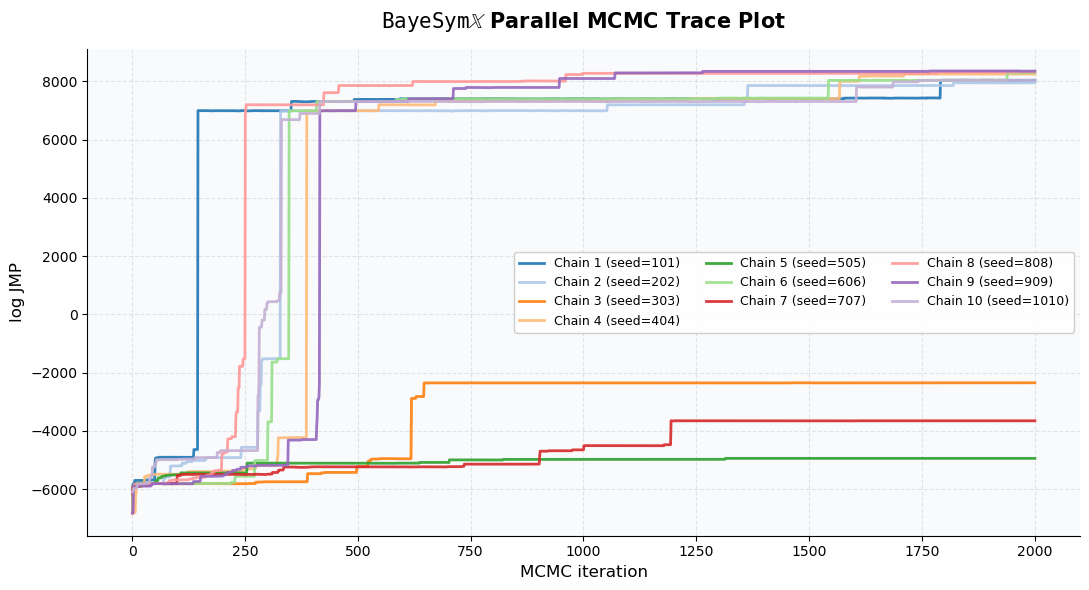


╔════════════════════════════════════════════════════════════════════════════════════════════════════╗
║                                              BayeSym𝕏                                              ║
║                                         Summary of Results                                         ║
╚════════════════════════════════════════════════════════════════════════════════════════════════════╝

Run overview
  • Ranked models     : 10 returned (10 requested)
  • Ranking statistic : log_JMP
  • Reduction method  : BIC and SymPy
  ✓ Evaluation        : training and held-out test metrics

 Raw symbolic models ───────────────────────────────────────────────────────────────────────────────
  
 Rank                                                                                                                    Raw expression  Train RMSE  Train MAE  Train R^2  Test RMSE  Test MAE  Test R^2      JMP
    1 3.04e-07 + 0.0154*((q * Ef)) + 0.123*(((Ef + Ef) * ((q + q) + (q + q))))

In [4]:
# ---------------------------------------------------------
# Run BayeSymX
# ---------------------------------------------------------

result_json = run_bayesymx(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,

    K=3,
    maxdepth=3,

    seeds=[
        101,
        202,
        303,
        404,
        505,
        606,
        707,
        808,
        909,
        1010
    ],

    maxiter=2000,
    burnin=0,
    thin=1,

    # Use the original Feynman variable names in the
    # resulting symbolic expressions.
    ftset=feature_columns,

    significant_digits=3,
    print_results=True,

    # Optional restricted operator set:
    # opset=[add, mul, sqrt_op],
    
    # Trace plots
    show_trace_plot=True,
    save_trace_plot=False,
    report_every=20,
    n_jobs=10
)


# ---------------------------------------------------------
# Convert the returned JSON string to a Python dictionary
# ---------------------------------------------------------

results = json.loads(result_json)

## Feynman Equation I_20_26 (HOQN): $F = q(E_f + Bv\sin(\theta))$

In [5]:
# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------

random_seed = 2026
sample_size = 2000       # Set to None to use all 100,000 rows
test_fraction = 0.10

data_path = Path("feynman_data/feynman_I_50_26.tsv")

data = pd.read_csv(data_path, sep="\t")

target_column = "target"

if target_column not in data.columns:
    raise ValueError(
        f"The dataset must contain a "
        f"{target_column!r} column."
    )

feature_columns = [
    column
    for column in data.columns
    if column != target_column
]

if not feature_columns:
    raise ValueError(
        "No feature columns were found."
    )

print(
    f"Loaded {data_path.name}: "
    f"{len(data):,} observations, "
    f"{len(feature_columns)} features."
)

print("Features: " + ", ".join(feature_columns))


# ---------------------------------------------------------
# Optional reproducible subsampling
# ---------------------------------------------------------

rng = np.random.default_rng(random_seed)

if sample_size is not None:
    if not isinstance(sample_size, int) or sample_size <= 0:
        raise ValueError(
            "sample_size must be a positive integer "
            "or None."
        )

    if sample_size > len(data):
        raise ValueError(
            f"sample_size={sample_size:,} exceeds the "
            f"{len(data):,} available observations."
        )

    sampled_indices = rng.choice(
        len(data),
        size=sample_size,
        replace=False,
    )

    data = (
        data.iloc[sampled_indices]
        .reset_index(drop=True)
    )

    print(
        f"Using a reproducible sample of "
        f"{len(data):,} observations."
    )


# ---------------------------------------------------------
# Construct X and y
# ---------------------------------------------------------

X = data[feature_columns].to_numpy(dtype=float)

y = data[target_column].to_numpy(dtype=float)

if not np.all(np.isfinite(X)):
    raise ValueError("The feature matrix contains non-finite values.")

if not np.all(np.isfinite(y)):
    raise ValueError("The target vector contains non-finite values.")


# ---------------------------------------------------------
# Reproducible train-test split
# ---------------------------------------------------------

if not 0.0 < test_fraction < 1.0:
    raise ValueError(
        "test_fraction must be between 0 and 1."
    )

indices = rng.permutation(X.shape[0])

n_test = max(
    1,
    int(round(test_fraction * X.shape[0])),
)

test_indices = indices[:n_test]
train_indices = indices[n_test:]

X_train = X[train_indices]
y_train = y[train_indices]

X_test = X[test_indices]
y_test = y[test_indices]

print(
    f"Training observations: {len(y_train):,}"
)

print(
    f"Test observations:     {len(y_test):,}"
)

Loaded feynman_I_50_26.tsv: 100,000 observations, 4 features.
Features: x1, omega, t, alpha
Using a reproducible sample of 2,000 observations.
Training observations: 1,800
Test observations:     200



╭──────────────────────────────────────────────────────────────────────╮
│                           Running BayeSym𝕏                           │
├──────────────────────────────────────────────────────────────────────┤
│  Parallel MCMC chains : 10                                           │
│  MCMC iterations      : 2,000 per chain                              │
│  Trees per forest     : 3                                            │
│  Operator set         : [add, mul, inv, neg, sin, cos, exp, cu, sq]  │
╰──────────────────────────────────────────────────────────────────────╯



Chain 1 | seed=101:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 2 | seed=202:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 3 | seed=303:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 4 | seed=404:   0%|          | 0/2000 [00:00<?, ?it/s]

...

Chain 6 | seed=606:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 7 | seed=707:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 8 | seed=808:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 9 | seed=909:   0%|          | 0/2000 [00:00<?, ?it/s]

Chain 10 | seed=1010:   0%|          | 0/2000 [00:00<?, ?it/s]

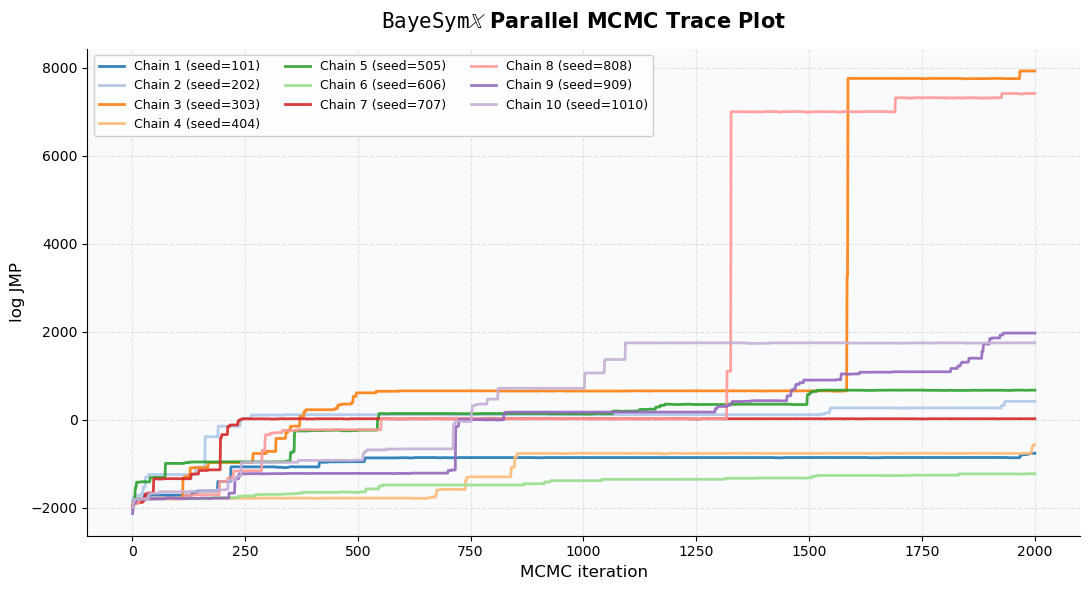


╔════════════════════════════════════════════════════════════════════════════════════════════════════╗
║                                              BayeSym𝕏                                              ║
║                                         Summary of Results                                         ║
╚════════════════════════════════════════════════════════════════════════════════════════════════════╝

Run overview
  • Ranked models     : 10 returned (10 requested)
  • Ranking statistic : log_JMP
  • Reduction method  : BIC and SymPy
  ✓ Evaluation        : training and held-out test metrics

 Raw symbolic models ───────────────────────────────────────────────────────────────────────────────
  
 Rank                                                                                                                                 Raw expression  Train RMSE  Train MAE  Train R^2  Test RMSE  Test MAE  Test R^2      JMP
    1 7.74e-06 + 0.5*((cos((t * omega)) * (x1 + x1))) + 0.25*((co

In [7]:
# ---------------------------------------------------------
# Run BayeSymX
# ---------------------------------------------------------

result_json = run_bayesymx(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,

    K=3,
    maxdepth=5,

    seeds=[
        101,
        202,
        303,
        404,
        505,
        606,
        707,
        808,
        909,
        1010
    ],

    maxiter=2000,
    burnin=0,
    thin=1,

    # Use the original Feynman variable names in the
    # resulting symbolic expressions.
    ftset=feature_columns,

    significant_digits=3,
    print_results=True,

    # Optional restricted operator set:
    # opset=[add, mul, sqrt_op],
    
    # Trace plots
    show_trace_plot=True,
    save_trace_plot=False,
    report_every=20,
    n_jobs=10,
    opset=[add, mul, inv, neg, sin, cos, exp, cu, sq]
)


# ---------------------------------------------------------
# Convert the returned JSON string to a Python dictionary
# ---------------------------------------------------------

results = json.loads(result_json)